# Diffusion Model


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from src.utils.paths import load_config, ensure_dir

In [2]:
config = load_config(PROJECT_ROOT / "config.yaml")

figures_dir = ensure_dir(PROJECT_ROOT / config["reports"]["figures_dir"])

diffusion_log_path = PROJECT_ROOT / "runs" / "diffusion" / "training_log.csv"
diffusion_samples_path = PROJECT_ROOT / "reports" / "figures" / "diffusion_samples_grid.png"
diffusion_generated_dir = PROJECT_ROOT / "outputs" / "generated_samples" / "diffusion"
diffusion_denoising_dir = PROJECT_ROOT / "outputs" / "generated_samples" / "diffusion" / "denoising_progress"

vae_samples_path = PROJECT_ROOT / "reports" / "figures" / "vae_samples_grid.png"
dcgan_samples_path = PROJECT_ROOT / "reports" / "figures" / "dcgan_samples_grid.png"

print("Diffusion log path:", diffusion_log_path)
print("Diffusion sample grid:", diffusion_samples_path)
print("Diffusion generated folder:", diffusion_generated_dir)
print("Diffusion denoising folder:", diffusion_denoising_dir)

Diffusion log path: e:\celeba-generative-comparison\runs\diffusion\training_log.csv
Diffusion sample grid: e:\celeba-generative-comparison\reports\figures\diffusion_samples_grid.png
Diffusion generated folder: e:\celeba-generative-comparison\outputs\generated_samples\diffusion
Diffusion denoising folder: e:\celeba-generative-comparison\outputs\generated_samples\diffusion\denoising_progress


In [3]:
diffusion_log = pd.read_csv(diffusion_log_path)

print("Training log shape:", diffusion_log.shape)
display(diffusion_log.head())
display(diffusion_log.tail())

Training log shape: (30, 5)


,epoch,train_loss,learning_rate,timesteps,inference_steps
0,1,0.030470,0.0001,1000,50
1,2,0.021249,0.0001,1000,50
2,3,0.020578,0.0001,1000,50
3,4,0.019957,0.0001,1000,50
4,5,0.019497,0.0001,1000,50


,epoch,train_loss,learning_rate,timesteps,inference_steps
25,26,0.018367,0.0001,1000,50
26,27,0.018186,0.0001,1000,50
27,28,0.018398,0.0001,1000,50
28,29,0.018355,0.0001,1000,50
29,30,0.018378,0.0001,1000,50


In [4]:
summary_cols = [
    "train_loss",
    "learning_rate",
    "timesteps",
    "inference_steps"
]

display(diffusion_log[summary_cols].describe())

,train_loss,learning_rate,timesteps,inference_steps
count,30.000000,3.000000e+01,30.0,30.0
mean,0.019303,1.000000e-04,1000.0,50.0
std,0.002219,2.756842e-20,0.0,0.0
min,0.018186,1.000000e-04,1000.0,50.0
25%,0.018457,1.000000e-04,1000.0,50.0
50%,0.018737,1.000000e-04,1000.0,50.0
75%,0.019141,1.000000e-04,1000.0,50.0
max,0.030470,1.000000e-04,1000.0,50.0


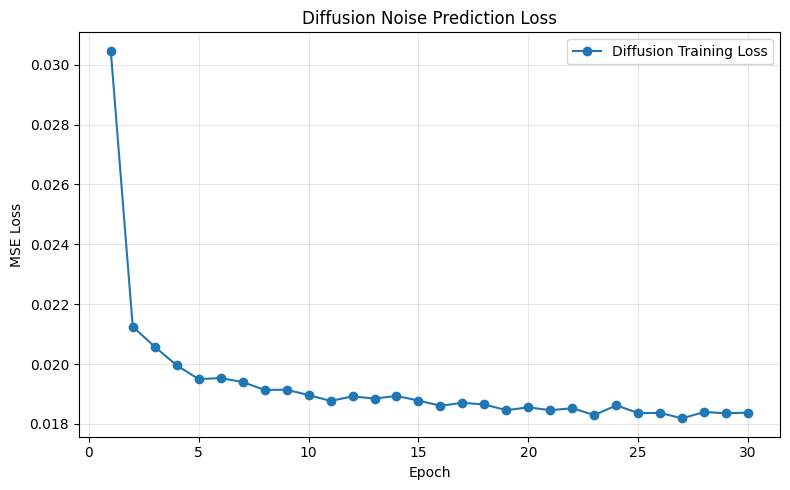

Saved to: e:\celeba-generative-comparison\reports\figures\diffusion_loss_curve.png


In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_log["epoch"],
    diffusion_log["train_loss"],
    marker="o",
    label="Diffusion Training Loss"
)

plt.title("Diffusion Noise Prediction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = figures_dir / "diffusion_loss_curve.png"
plt.savefig(loss_curve_path, dpi=150)
plt.show()

print("Saved to:", loss_curve_path)

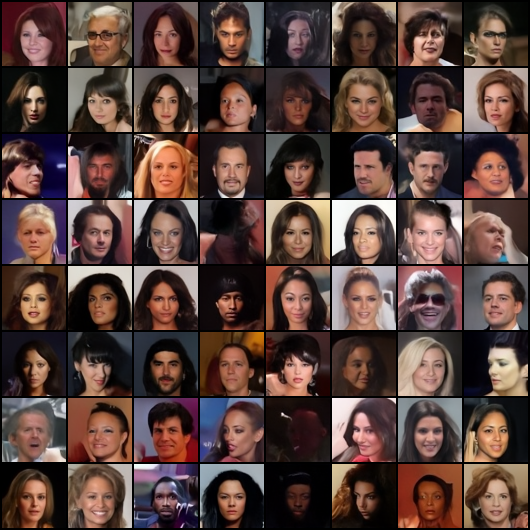

In [6]:
if diffusion_samples_path.exists():
    display(Image.open(diffusion_samples_path))
else:
    print("Diffusion sample grid not found:", diffusion_samples_path)

## Diffusion Generated Samples

After 30 epochs, the diffusion model produced the strongest synthetic face samples among the three model families. The generated images show clear facial structure, realistic colour variation, sharper hair and skin regions, and strong diversity across samples.

Compared with the VAE, the diffusion outputs are much sharper and contain more fine visual detail. Compared with the DCGAN, the diffusion outputs appear more stable and less affected by distorted facial artifacts or repeated same-face patterns.

Overall, the diffusion model provides the strongest visual quality in this project.

In [9]:
generated_files = sorted(diffusion_generated_dir.glob("epoch_*_generated.png"))
denoising_files = sorted(diffusion_denoising_dir.glob("*denoising_progress.png"))

Displaying: epoch_001_generated.png


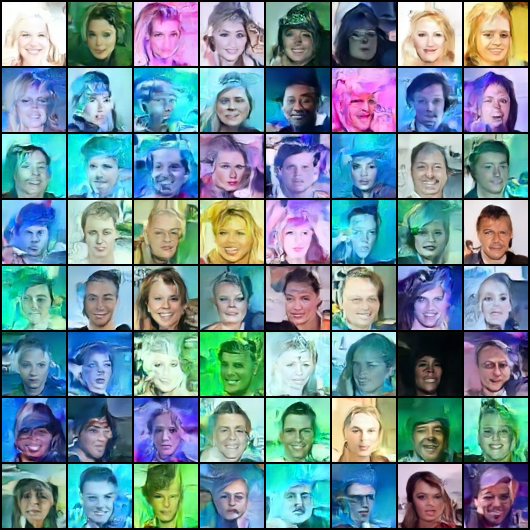

Displaying: epoch_010_generated.png


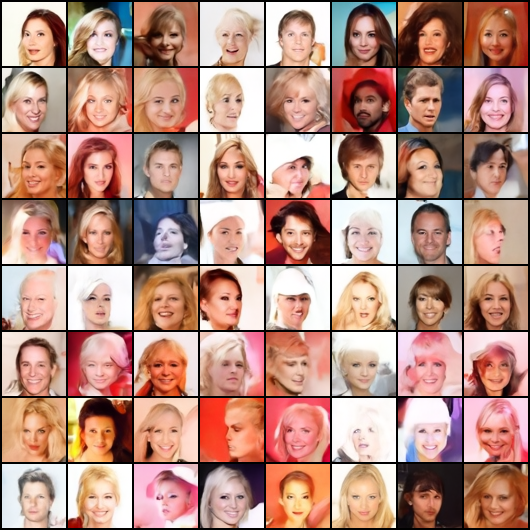

Displaying: epoch_020_generated.png


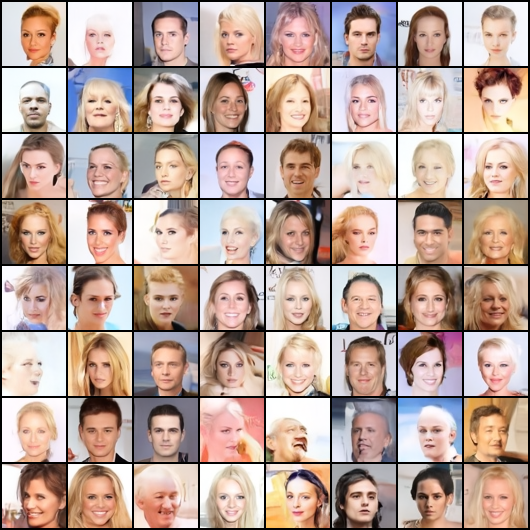

Displaying: epoch_030_generated.png


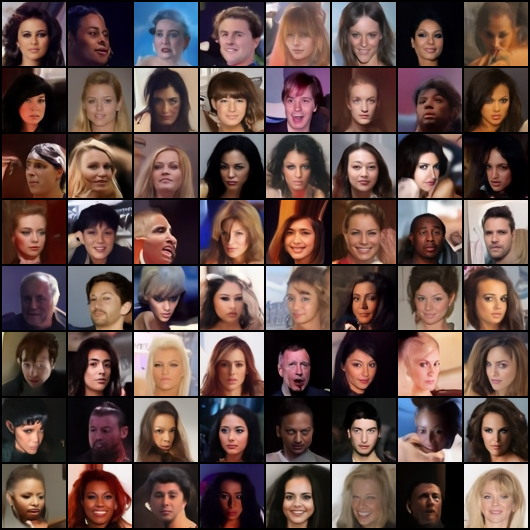

In [10]:
selected_epochs = ["epoch_001", "epoch_010", "epoch_020", "epoch_030"]

for epoch_name in selected_epochs:
    matched_files = [p for p in generated_files if epoch_name in p.name]

    if matched_files:
        path = matched_files[0]
        print("Displaying:", path.name)
        display(Image.open(path))
    else:
        print("No generated sample file found for:", epoch_name)

Displaying: epoch_030_denoising_progress.png


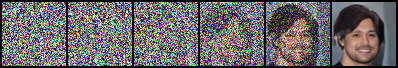

In [11]:
if len(denoising_files) > 0:
    latest_denoising = denoising_files[-1]
    print("Displaying:", latest_denoising.name)
    display(Image.open(latest_denoising))
else:
    print("No denoising progression files found.")

VAE Generated Samples


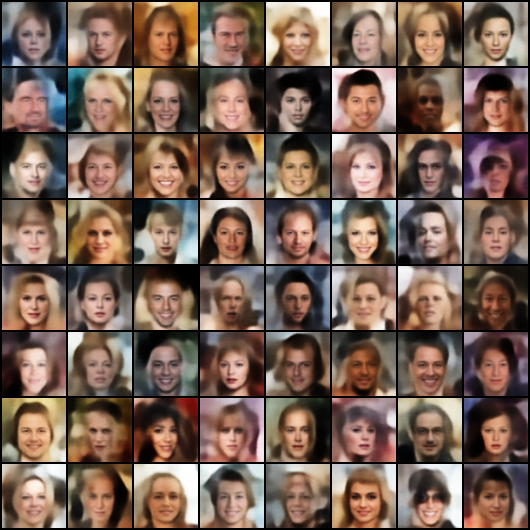

DCGAN Generated Samples


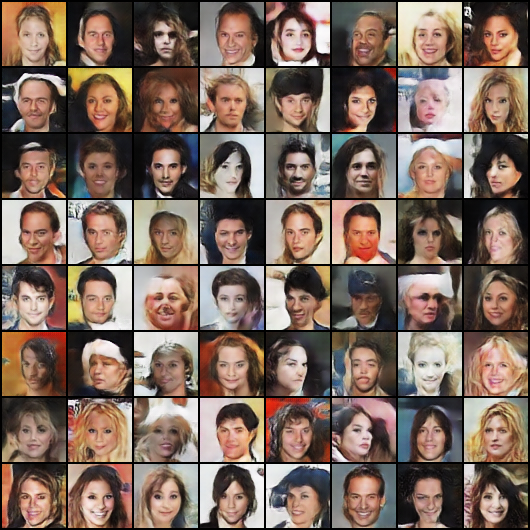

Diffusion Generated Samples


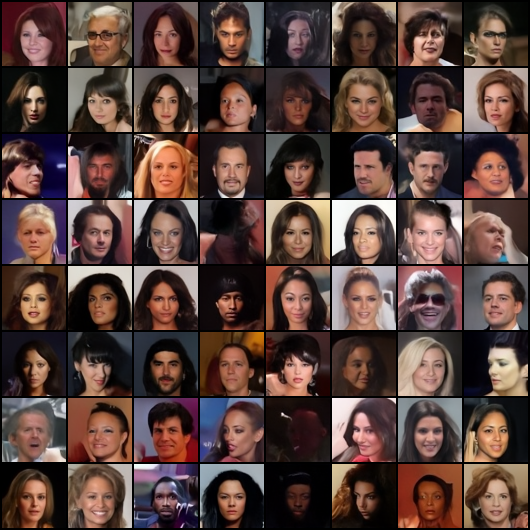

In [12]:
if vae_samples_path.exists():
    print("VAE Generated Samples")
    display(Image.open(vae_samples_path))
else:
    print("VAE sample grid not found:", vae_samples_path)

if dcgan_samples_path.exists():
    print("DCGAN Generated Samples")
    display(Image.open(dcgan_samples_path))
else:
    print("DCGAN sample grid not found:", dcgan_samples_path)

if diffusion_samples_path.exists():
    print("Diffusion Generated Samples")
    display(Image.open(diffusion_samples_path))
else:
    print("Diffusion sample grid not found:", diffusion_samples_path)

## VAE vs DCGAN vs Diffusion

The three models show clear differences in generative behaviour.

The VAE trained smoothly and produced diverse face-like samples, but the outputs were blurry and lacked fine detail. The tuned DCGAN produced sharper and more visually detailed samples than the VAE, but it showed adversarial instability and some generated images contained artifacts.

The diffusion model produced the strongest results overall. Its samples were more realistic, more stable, and more diverse than the VAE and DCGAN outputs. The diffusion model also avoided the obvious repeated same-face behaviour seen in the first DCGAN run.

Overall comparison:

- VAE: stable but blurry
- DCGAN: sharper but unstable
- Diffusion: best visual quality and stability

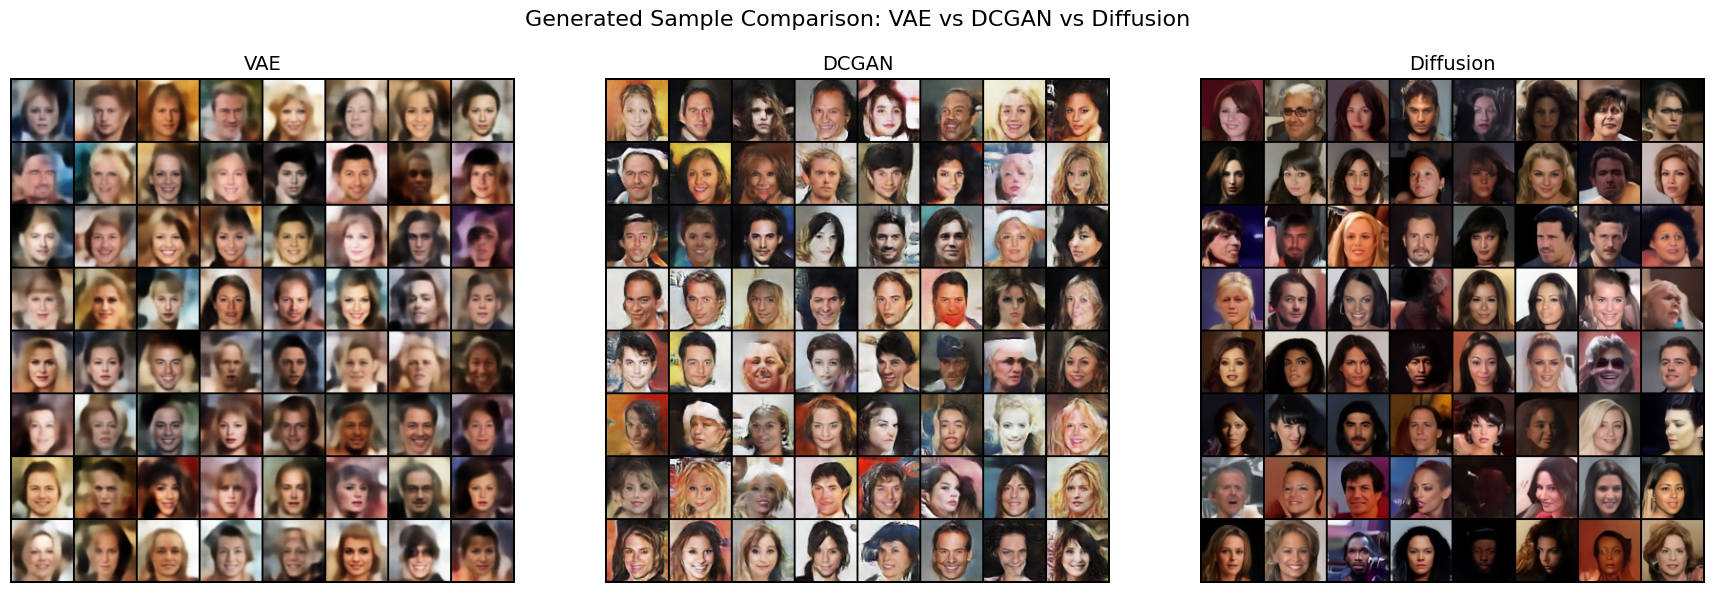

Saved to: e:\celeba-generative-comparison\reports\figures\model_comparison_grid.png


In [13]:
image_paths = {
    "VAE": vae_samples_path,
    "DCGAN": dcgan_samples_path,
    "Diffusion": diffusion_samples_path,
}

available_images = {
    name: Image.open(path).convert("RGB")
    for name, path in image_paths.items()
    if path.exists()
}

if len(available_images) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, (name, image) in zip(axes, available_images.items()):
        ax.imshow(image)
        ax.set_title(name, fontsize=14)
        ax.axis("off")

    plt.suptitle("Generated Sample Comparison: VAE vs DCGAN vs Diffusion", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    comparison_path = figures_dir / "model_comparison_grid.png"
    plt.savefig(comparison_path, dpi=150)
    plt.show()

    print("Saved to:", comparison_path)
else:
    print("Not all model sample grids were found.")
    print("Available:", list(available_images.keys()))

## Ethics and Memorisation Note

CelebA contains real human face images, so the generated samples should be treated carefully. This project is for educational generative modelling only and does not aim to imitate or reproduce any specific real person.

Because the diffusion samples are visually strong, the next evaluation step should include a nearest-neighbour check. This will compare generated faces against the closest real training images to inspect whether the model is generating new synthetic samples or closely copying training images.

## Diffusion Model Summary

The diffusion model successfully learned to generate high-quality synthetic face images from random noise. Compared with the VAE and DCGAN baselines, it produced the strongest visual results, with clearer facial structure, better diversity, and fewer obvious artifacts.

The training loss decreased steadily and remained stable, showing that the U-Net learned the noise-prediction task effectively. The denoising progression further demonstrates the reverse diffusion process, where random noise is gradually transformed into a coherent synthetic face.

This model will be used as the strongest generative model in the final model comparison and Streamlit dashboard.